In [2]:
import pandas as pd
import numpy as np
import seaborn as sns



In [4]:
df=pd.read_csv(r"C:\Users\DELL\Desktop\telecom churn capstone project\telecom_dataset.csv")

In [5]:
df.shape

(7043, 21)

In [11]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [10]:
df['SeniorCitizen'].unique

<bound method Series.unique of 0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: int64>

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# converting total_charge into numeric value which saved as str(object)


In [15]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [19]:
#encode int data type columns into str data type

In [17]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0:'No',1:'Yes'})

In [18]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [20]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [21]:
df.columns=df.columns.str.capitalize()

In [22]:
df.columns

Index(['Customerid', 'Gender', 'Seniorcitizen', 'Partner', 'Dependents',
       'Tenure', 'Phoneservice', 'Multiplelines', 'Internetservice',
       'Onlinesecurity', 'Onlinebackup', 'Deviceprotection', 'Techsupport',
       'Streamingtv', 'Streamingmovies', 'Contract', 'Paperlessbilling',
       'Paymentmethod', 'Monthlycharges', 'Totalcharges', 'Churn'],
      dtype='str')

In [32]:
df.select_dtypes(include=[np.number])

,Tenure,Monthlycharges,Totalcharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


In [30]:
# checking outlier in numeric values using the  IQR method

In [35]:
# with the help of visual

<Axes: >

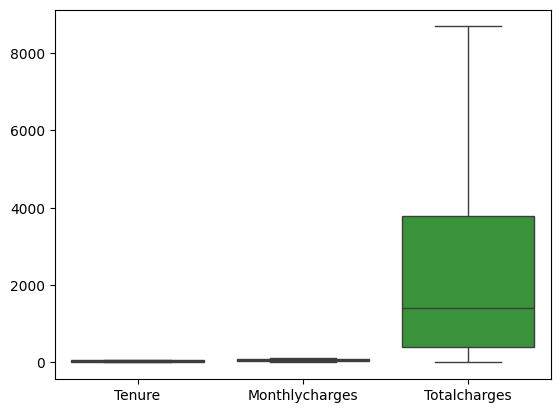

In [34]:
sns.boxplot(data=df[['Tenure','Monthlycharges','Totalcharges']])

In [36]:
# checking outlier with the code

In [41]:
for col in['Tenure','Monthlycharges','Totalcharges']:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5* IQR
    upper=Q3+1.5 * IQR
    outliers=df[(df[col]<lower) | (df[col]>upper)]
    print(f"{col}:{len(outliers)} outliers")

Tenure:0 outliers
Monthlycharges:0 outliers
Totalcharges:0 outliers


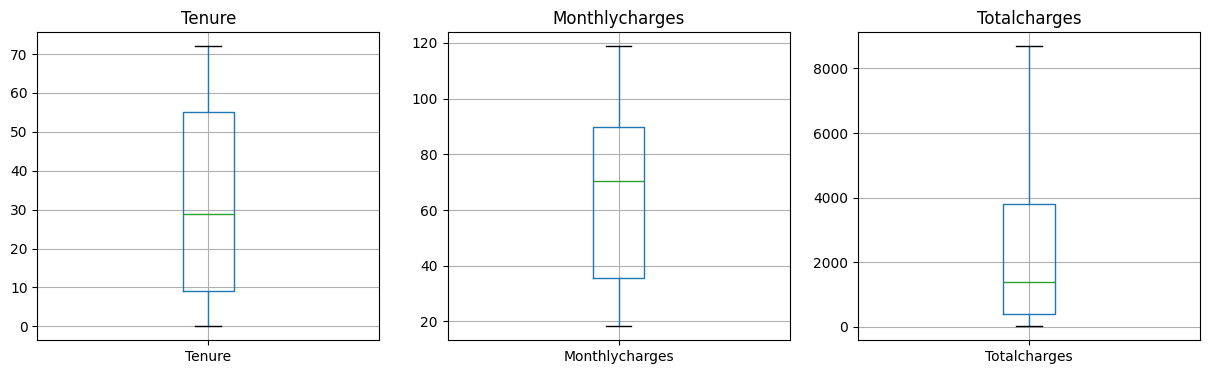

In [29]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Tenure','Monthlycharges','Totalcharges']):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.show()

In [43]:
df.head(50)

,Customerid,Gender,Seniorcitizen,Partner,Dependents,Tenure,Phoneservice,Multiplelines,Internetservice,Onlinesecurity,...,Deviceprotection,Techsupport,Streamingtv,Streamingmovies,Contract,Paperlessbilling,Paymentmethod,Monthlycharges,Totalcharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [45]:
# bucketing of tenure column

In [46]:
df['TenureGroup']=pd.cut(df['Tenure'],bins=[-1,12,24,48,72], labels=['0-12months','13-24months','25-48months','49-72months'])

In [66]:
# Reduce redundacny of categories

In [53]:
df['Multiplelines'].unique()
df['Onlinesecurity'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [54]:
df['Onlinesecurity'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [61]:
df['Phoneservice'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [63]:
df['Onlinebackup'].unique()

<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

In [65]:
df['Streamingtv'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [67]:
df.columns

Index(['Customerid', 'Gender', 'Seniorcitizen', 'Partner', 'Dependents',
       'Tenure', 'Phoneservice', 'Multiplelines', 'Internetservice',
       'Onlinesecurity', 'Onlinebackup', 'Deviceprotection', 'Techsupport',
       'Streamingtv', 'Streamingmovies', 'Contract', 'Paperlessbilling',
       'Paymentmethod', 'Monthlycharges', 'Totalcharges', 'Churn',
       'TenureGroup'],
      dtype='str')

In [68]:
addon_cols=['Onlinesecurity', 'Onlinebackup', 'Deviceprotection', 'Techsupport','Streamingtv', 'Streamingmovies']
for col in addon_cols:
    df[col]=df[col].replace('No internet service','No')

In [71]:
# verfiy
df['Onlinebackup'].value_counts()

Onlinebackup
No     4614
Yes    2429
Name: count, dtype: int64

In [72]:
# num add on services collab six col into one

In [74]:
df['NumAddOnServices']=(df[addon_cols]=='Yes').sum(axis=1)

In [76]:
df['NumAddOnServices'].value_counts().sort_index()

NumAddOnServices
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

In [77]:
df['Average Monthly Spend']=df['Totalcharges']/df['Tenure'].replace(0,1)

In [79]:
df[['Tenure', 'Totalcharges', 'Monthlycharges', 'Average Monthly Spend']].head(10)

,Tenure,Totalcharges,Monthlycharges,Average Monthly Spend
0,1,29.85,29.85,29.850000
1,34,1889.50,56.95,55.573529
2,2,108.15,53.85,54.075000
3,45,1840.75,42.30,40.905556
4,2,151.65,70.70,75.825000
5,8,820.50,99.65,102.562500
6,22,1949.40,89.10,88.609091
7,10,301.90,29.75,30.190000
8,28,3046.05,104.80,108.787500
9,62,3487.95,56.15,56.257258


In [80]:
# EDA with the help of chart ploting

<function matplotlib.pyplot.show(close=None, block=None)>

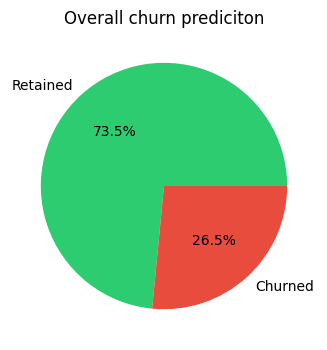

In [85]:
plt.figure(figsize=(8,4))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', 
                                     colors=['#2ecc71','#e74c3c'],
                                     labels=['Retained','Churned'])
plt.title("Overall churn prediciton")
plt.show

In [86]:
# Churn rate by tenure Group

<function matplotlib.pyplot.show(close=None, block=None)>

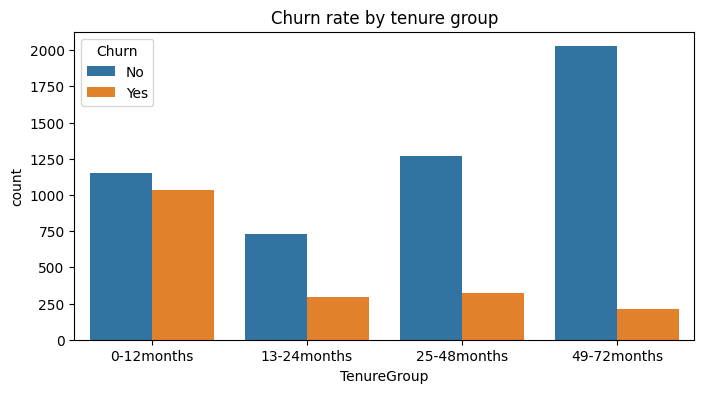

In [93]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='TenureGroup',hue='Churn')
plt.title('Churn rate by tenure group')
plt.show

In [91]:
# Churn rate by Internet service provider

<function matplotlib.pyplot.show(close=None, block=None)>

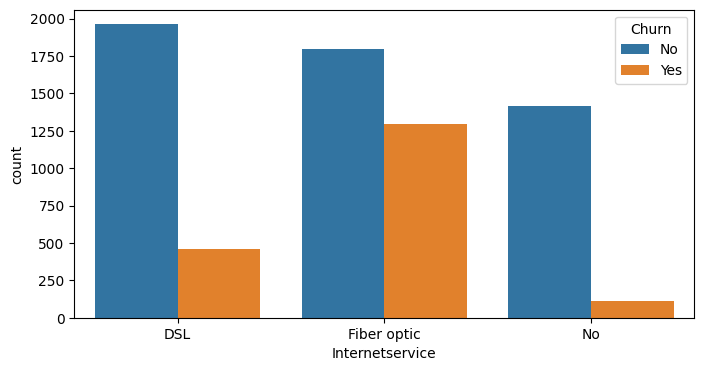

In [94]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='Internetservice',hue='Churn')
plt.show

In [97]:
# Churn by the num add on services(feature enginerring columns)

<function matplotlib.pyplot.show(close=None, block=None)>

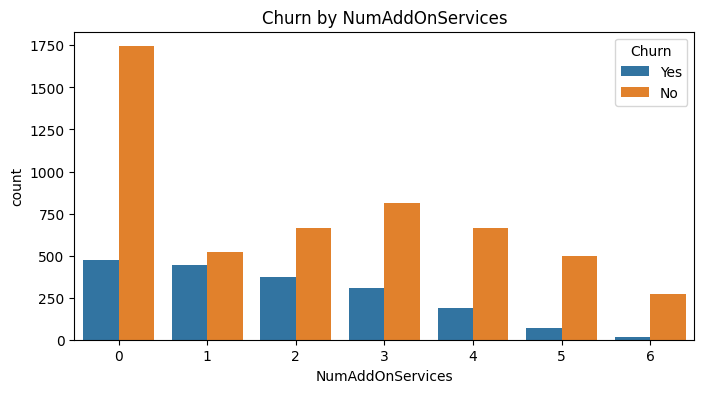

In [96]:
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='NumAddOnServices',hue='Churn')
plt.title('Churn by NumAddOnServices')
plt.show

In [105]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumAddOnServices,AvgMonthlySpend
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,1,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,2,55.573529


In [106]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumAddOnServices,AvgMonthlySpend
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,1,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,2,55.573529


In [107]:
# prepare data for ML

In [108]:
df_ml=df.copy()

In [118]:
df_ml.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,NumAddOnServices,AvgMonthlySpend
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,1,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,2,55.573529


In [111]:
# Dropping columns not useful for prediction

In [120]:
df_ml.drop(['customerID','TenureGroup'],axis=1, inplace=True)

In [123]:
# encode all categorical value into numerical value because ML understand only numerical value

In [125]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col]=le.fit_transform(df_ml[col])

C:\Users\DELL\AppData\Local\Temp\ipykernel_20248\2027599333.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_ml.select_dtypes(include='object').columns:


In [126]:
df_ml.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NumAddOnServices,AvgMonthlySpend
0,0,0,1,0,1,0,0,0,0,1,...,0,0,0,1,2,29.85,29.85,0,1,29.850000
1,1,0,0,0,34,1,0,0,1,0,...,0,0,1,0,3,56.95,1889.50,0,2,55.573529


In [127]:
# Split data

In [134]:
X=df_ml.drop('Churn',axis=1)
y=df_ml['Churn']

In [129]:
# 80% and 20%

In [132]:
from sklearn.model_selection import train_test_split

In [135]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [136]:
X_train.shape[0]

5634

In [138]:
X_test.shape[0]

1409

In [139]:
# Train Model

In [142]:
from sklearn.linear_model import LogisticRegression

In [145]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [146]:
# evaluate model

In [147]:
y_pred=model.predict(X_test)

In [148]:
# check accuracy

In [150]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [151]:
print(f'\nModel Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))


Model Accuracy: 81.48%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.86      0.90      0.88      1036
     Churned       0.68      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



In [152]:
# Confusion Matrix

<function matplotlib.pyplot.show(close=None, block=None)>

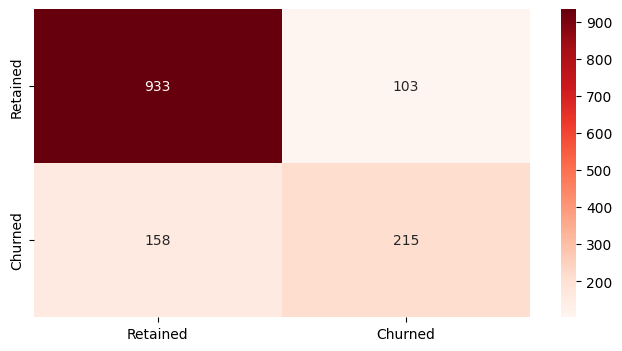

In [157]:
plt.figure(figsize=(8,4))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',xticklabels=['Retained','Churned'],
                                            yticklabels=['Retained','Churned'])
plt.show

In [159]:
import numpy as np

# Create a sample customer
sample_customer = pd.DataFrame([{
    'gender': 1,              # Male
    'SeniorCitizen': 0,       # No
    'Partner': 0,             # No
    'Dependents': 0,          # No
    'tenure': 2,              
    'PhoneService': 1,        # Yes
    'MultipleLines': 0,       # No
    'InternetService': 1,     # Fiber optic
    'OnlineSecurity': 0,      # No
    'OnlineBackup': 0,        # No
    'DeviceProtection': 0,    # No
    'TechSupport': 0,         # No
    'StreamingTV': 0,         # No
    'StreamingMovies': 0,     # No
    'Contract': 0,            # Month-to-month
    'PaperlessBilling': 1,    # Yes
    'PaymentMethod': 2,       # Electronic check
    'MonthlyCharges': 85.0,   # High charges
    'TotalCharges': 170.0,    # Low total (new customer)
    'NumAddOnServices': 0,    # No addons
    'AvgMonthlySpend': 85.0   # Same as monthly
}])

In [160]:
prediction=model.predict(sample_customer)

In [163]:
probability = model.predict_proba(sample_customer)
if prediction[0] == 1:
    print('Churn Prediction: YES - Will Churn')
else:
    print('Churn Prediction: NO - Will Stay')

Churn Prediction: YES - Will Churn
